### 1. Carga y Entrenamiento del modelo

In [2]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────
# 1. CARGAR DATOS
# ─────────────────────────────────────────
engine = create_engine('sqlite:///../db/ventas.db', echo=False)
df = pd.read_sql("SELECT * FROM ventas", engine)

df['fecha_venta'] = pd.to_datetime(df['fecha_venta'])
df['mes'] = df['fecha_venta'].dt.month
df['dia_semana'] = df['fecha_venta'].dt.dayofweek

print("Shape:", df.shape)
df.head(3)

Shape: (5000, 9)


,id,fecha_venta,tipo_venta,empleado,categoria,total,es_entregado,mes,dia_semana
0,1,2023-09-20,WhatsApp,Luis,deportes,111.55,1,9,2
1,2,2023-07-02,WhatsApp,Carlos,muebles,112.13,1,7,6
2,3,2023-02-26,WhatsApp,Luis,tecnológico,0.00,0,2,6


In [14]:
# ─────────────────────────────────────────
# 2. PREPARAR FEATURES
# ─────────────────────────────────────────
le_empleado  = LabelEncoder()
le_categoria = LabelEncoder()
le_tipo      = LabelEncoder()

df['empleado_enc']  = le_empleado.fit_transform(df['empleado'])
df['categoria_enc'] = le_categoria.fit_transform(df['categoria'])
df['tipo_venta_enc'] = le_tipo.fit_transform(df['tipo_venta'])

# Features y target
X = df[['empleado_enc', 'categoria_enc', 'tipo_venta_enc', 'mes', 'dia_semana']]
y = df['es_entregado']

print("Features shape:", X.shape)
print("Distribucion target:\n", y.value_counts())

Features shape: (5000, 5)
Distribucion target:
 es_entregado
1    4034
0     966
Name: count, dtype: int64


In [15]:
# ─────────────────────────────────────────
# 3. SPLIT 80% TRAIN / 20% TEST
# ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # mantiene la proporcion 80/20 en ambos conjuntos
)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test:  {X_test.shape[0]} registros")

Train: 4000 registros
Test:  1000 registros


In [16]:
# ─────────────────────────────────────────
# 4. ENTRENAR MODELO
# ─────────────────────────────────────────
modelo = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

modelo.fit(X_train, y_train)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


Accuracy: 0.729

Classification Report:
              precision    recall  f1-score   support

   Cancelado       0.22      0.16      0.18       193
   Entregado       0.81      0.87      0.84       807

    accuracy                           0.73      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.70      0.73      0.71      1000



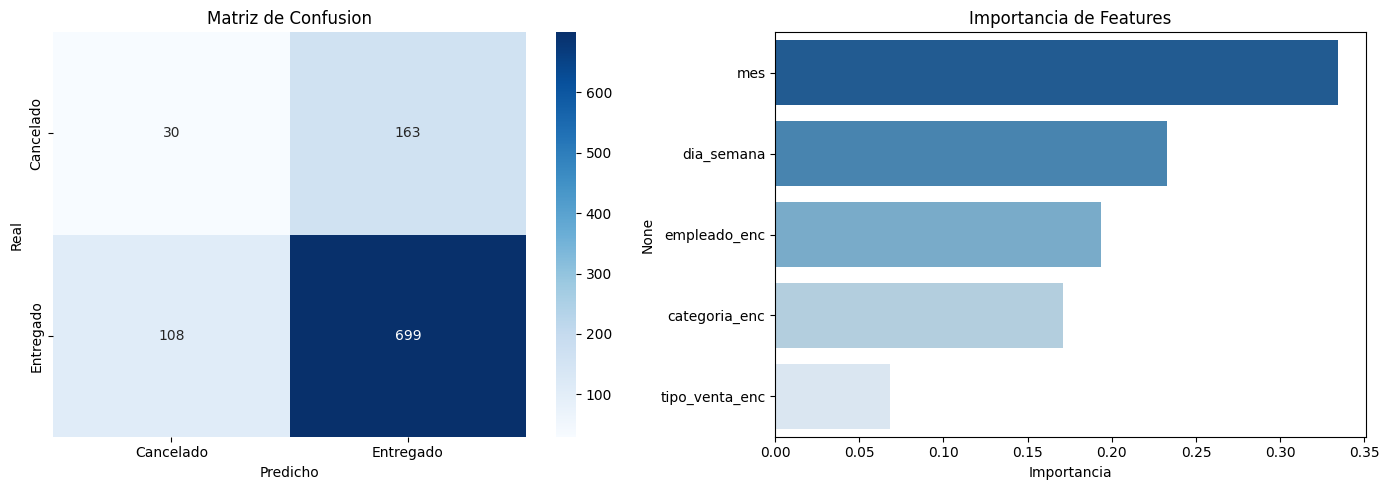

In [17]:
# ─────────────────────────────────────────
# 5. EVALUAR MODELO
# ─────────────────────────────────────────
y_pred = modelo.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Cancelado', 'Entregado']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cancelado', 'Entregado'],
            yticklabels=['Cancelado', 'Entregado'], ax=axes[0])
axes[0].set_title("Matriz de Confusion")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

# Importancia de features
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=importancias.values, y=importancias.index,
            hue=importancias.index, legend=False,
            palette='Blues_r', ax=axes[1])
axes[1].set_title("Importancia de Features")
axes[1].set_xlabel("Importancia")

plt.tight_layout()
plt.savefig("../reports/modelo_evaluacion.png", dpi=150, bbox_inches='tight')
plt.show()

In [20]:
import joblib
import os

os.makedirs("../model", exist_ok=True)

# Guardar modelo
joblib.dump(modelo, '../model/random_forest.pkl')

# Guardar encoders — importantes para cuando predicas datos nuevos
joblib.dump(le_empleado,  '../model/le_empleado.pkl')
joblib.dump(le_categoria, '../model/le_categoria.pkl')
joblib.dump(le_tipo,      '../model/le_tipo.pkl')

print("Modelo guardado:")
print("  ../model/random_forest.pkl")
print("  ../model/le_empleado.pkl")
print("  ../model/le_categoria.pkl")
print("  ../model/le_tipo.pkl")

Modelo guardado:
  ../model/random_forest.pkl
  ../model/le_empleado.pkl
  ../model/le_categoria.pkl
  ../model/le_tipo.pkl
